In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 

fileName ='Raw_Raudah_16bpm_0.5m.bin'

# Read Data Reference 
polar = pd.read_csv('Polar_16bpm_0.5m_raudah.txt', delimiter=';')
# ecg = pd.read_csv('12bpm_ita_Polar_H10_89BA4523_20230405_162734_ECG.txt', delimiter=';')
oximeter_1 = 'Oxi_16_bpm_0.5m_raudah.csv'
x=np.loadtxt('Bitalino_16bpm_0.5m_raudah.txt')
HR_polar= np.array(polar.get("HR [bpm]"))
df1 = pd.read_csv(oximeter_1)
#  df2 = pd.read_excel(oximeter_2) 
HR_oxi= np.array(df1.get("PULSE"))
subject_id = 16
user_name ='Raudah'
# pol = HR_polar[43:163]
# ox = HR_oxi[58:178]
pol = HR_polar[55:175]
ox = HR_oxi[75:195]
# Bitalino 

120.0


Text(0.5, 0, 'Number of Samples')

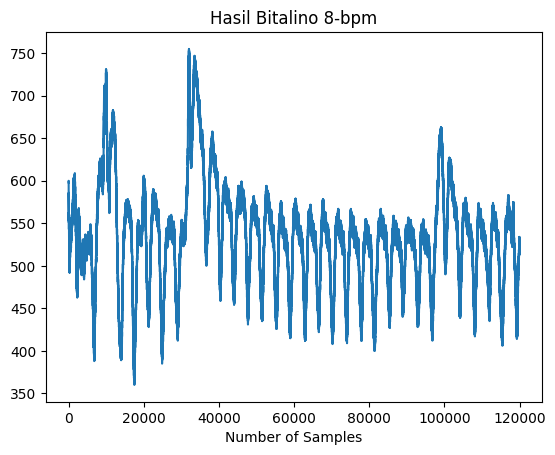

In [2]:
# Bitalino 
ref_br =x[:,5]
bitalino = ref_br[20000:140000]
plt.title("Hasil Bitalino 8-bpm")
plt.plot(bitalino)
# plt.plot(ref_br)
print(len(bitalino)/1000)
plt.xlabel("Number of Samples")

In [3]:
def read_raw(fileName):
    numADCSamples = 200 # number of ADC samples per chirp
    numADCBits = 16 # number of ADC bits per sample
    numRX = 4 # number of receivers
    numLanes = 2 # do not change. number of lanes is always 2
    isReal = 0 # set to 1 if real only data, 0 if complex data0
    fid = open(fileName,'rb')
    adcData = np.fromfile(fid, dtype='int16')
    if numADCBits != 16:
        l_max = 2**(numADCBits-1)-1
        adcData[adcData > l_max] = adcData[adcData > l_max] - 2**numADCBits
    fid.close()
    fileSize = adcData.shape[0]

    if isReal:
        numChirps = fileSize//numADCSamples//numRX
        LVDS = np.zeros((fileSize,), dtype=np.int16)
        LVDS = adcData.reshape(numADCSamples*numRX, numChirps, order='F').T
    else:
        numChirps = fileSize//2//numADCSamples//numRX
        LVDS = np.zeros((fileSize//2,), dtype=np.complex64)
        counter = 0
        for i in range(0, fileSize-1, 4):
            LVDS[counter] = adcData[i] + 1j*adcData[i+2]
            LVDS[counter+1] = adcData[i+1] + 1j*adcData[i+3]
            counter += 2
        LVDS = LVDS.reshape(numADCSamples*numRX, numChirps, order='F').T

    adcData = np.zeros((numRX,numChirps*numADCSamples), dtype=np.complex64)
    for row in range(numRX):
        for i in range(numChirps):
            adcData[row, i*numADCSamples:(i+1)*numADCSamples] = LVDS[i, row*numADCSamples:(row+1)*numADCSamples]

    retVal = adcData
    return retVal

In [4]:
Radar_data = read_raw(fileName)

In [5]:
# Radar_data.shape
n_rx = 4 
n_fft = 1024
n_adc = 200
n_chirp = 2
raw_data = Radar_data
raw_new =raw_data.reshape((n_rx,n_adc*n_chirp,-1), order='F')
raw_new.shape

(4, 400, 2400)

In [6]:
data_len = raw_new.shape[2]
data_len

2400

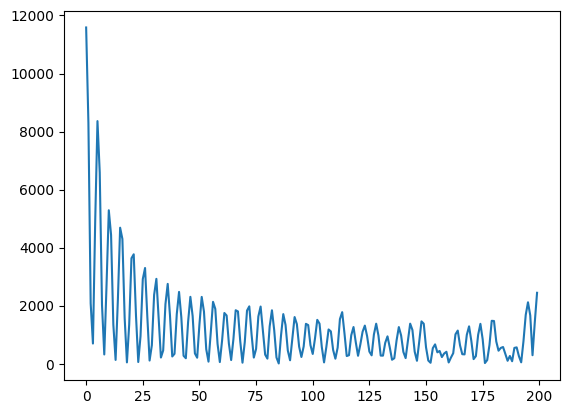

In [7]:
from scipy.fft import fft, fftfreq, fftshift
an1 = raw_new[0,:,:]
a = fft(an1[:,300], n=1024)
plt.plot(abs(a[:200]))

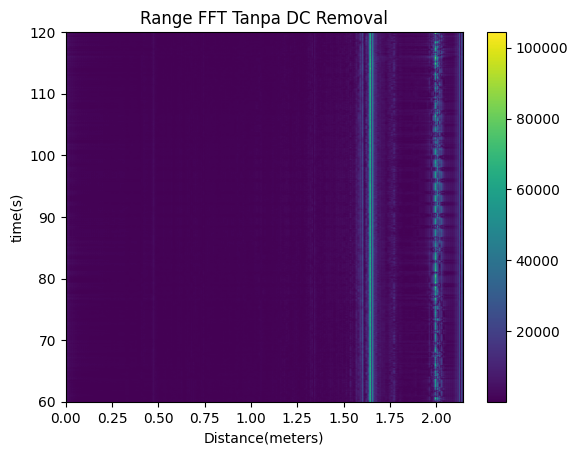

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hamming

# retVal = np.fromfile('./demo.bin', dtype=np.int16)
numChirps = 2400
numADCSamples = 400
RX1data = raw_new[0,:,:]
# RX2data = np.reshape(retVal[numChirps*numADCSamples:2*numChirps*numADCSamples], (numADCSamples, numChirps), order='F')
# RX3data = np.reshape(retVal[2*numChirps*numADCSamples:3*numChirps*numADCSamples], (numADCSamples, numChirps), order='F')
# RX4data = np.reshape(retVal[3*numChirps*numADCSamples:4*numChirps*numADCSamples], (numADCSamples, numChirps), order='F')
c = 3.0e8
slope = 70e12
Tc = 57e-6
B = slope * Tc
Fs = 4e6
f0 = 77.0e9
lambda_ = c / f0
d = lambda_ / 2
frame = raw_new.shape[2]
Tf = 0.05
N = 1024
# Extract data for range calculations
data = RX1data[:, ::2]
index = np.arange(numADCSamples)
# Generate window
range_win = np.hamming(numADCSamples)
# Apply window to data
din_win = data * range_win[:, np.newaxis]
# Compute FFT
datafft = np.fft.fft(din_win, axis=0)
# convert sample indices to frequency bins
freq_bin = index * Fs / numADCSamples
# convert frequency bins to range bins
range_bin = freq_bin * c / 2 / slope
dBFs = 20 * np.log10(np.abs(datafft) / 2 ** 16)
# generate time index
Time = np.arange(Tf * frame, -Tf, -Tf)
# g = datafft
# array_new = g[:400, :]
# array_new.shape
# plot the range-FFT heatmap
# plt.imshow(data, cmap='gray', extent=[0, 1, 0, 1])
plt.figure(1)
plt.imshow(np.abs(datafft.T), extent=[range_bin[0], range_bin[100], Time[1200], Time[0]], aspect='auto')
plt.colorbar()
plt.title('Range FFT Tanpa DC Removal')
plt.xlabel('Distance(meters)')
plt.ylabel('time(s)')
plt.show()

In [9]:
from scipy.fft import fft, fftfreq, fftshift
def Range_FFT(InputData):
    OutputData = np.zeros((n_rx, n_fft, data_len), dtype=complex)
    dc_removal = np.zeros((n_rx, n_adc*2 , data_len), dtype=complex)
    for i in range(n_rx):
        for j in range(data_len):
#             window = np.hamming(params['n_fft']//4)
            dc_removal[i,:,j]= InputData[i,:,j] - np.mean(InputData[i,:,j])
            OutputData[i,:,j]= fft((InputData[i,:,j]), n=n_fft)
    return OutputData

def MTI(hasil_fft):
    clutter = np.zeros((hasil_fft.shape[0], n_fft, hasil_fft.shape[-1]),dtype=complex)
    OutputData = np.zeros((hasil_fft.shape[0],n_adc*2, hasil_fft.shape[-1]),dtype=complex)
    alpha = 0.01
    for i in np.arange(hasil_fft.shape[0]):
        for j in np.arange(1,hasil_fft.shape[-1]):
            clutter[i,:,j] = np.dot(alpha,hasil_fft[i,:,j])+ np.dot((1-alpha),clutter[i,:,j-1])
            OutputData[i,:,j] = hasil_fft[i,np.arange(n_adc*2),j]-(clutter[i,range(0,n_adc*2),j])
    return OutputData

In [10]:
# Range FFT plus dc removal 
FFT_hasil = Range_FFT(raw_new) # hasil FFT
# FFT_hasil.shape
Hasil_mti = MTI(FFT_hasil)

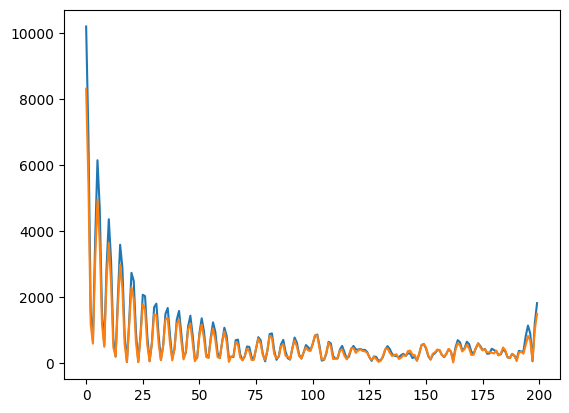

In [11]:
an1 = FFT_hasil[0,:,:]
an1_mti = Hasil_mti[0,:,:]
b = abs(an1[:,20])
c = abs(an1_mti[:,20])
plt.plot(b[:200])
plt.plot(c[:200])


In [12]:
mti_rx1 = Hasil_mti[0,:,:]
mti_rx2 = Hasil_mti[1,:,:]
mti_rx3 = Hasil_mti[2,:,:]
mti_rx4 = Hasil_mti[3,:,:]

In [13]:
def map_loc(data_mti):
    Range_Map_An1 =[]
    index_max =[]
    for i in range(1,data_len):
    # Input data From MTI each Antenna 
        awal_an1 = data_mti[:,i] 
        abs_mti_1 = abs(awal_an1)
        peak_loc_an1 = np.argmax(abs_mti_1[25:100])
        rslt_peak_1 = 25+peak_loc_an1
        map_loc_an1 = awal_an1[rslt_peak_1]
        index_max.append(abs(rslt_peak_1))
        Range_Map_An1.append(map_loc_an1)
    return index_max, Range_Map_An1

In [14]:
 # Range Map Location 
Antena1 = np.array(Hasil_mti[0,:,:],dtype='object')
Antena2 = np.array(Hasil_mti[1,:,:],dtype='object')
Antena3 = np.array(Hasil_mti[2,:,:],dtype='object')
Antena4 = np.array(Hasil_mti[3,:,:],dtype='object')

In [15]:
##Map Lokasinya 
# Ini adalah data range_bin 
map_locA1,Map_loc_An1 = np.array(map_loc(Antena1))
map_locA2,Map_loc_An2 = np.array(map_loc(Antena2))
map_locA3,Map_loc_An3 = np.array(map_loc(Antena3))
map_locA4,Map_loc_An4 = np.array(map_loc(Antena4))

In [16]:
def dacm(data):
    psi=[]
    for i in range(1,data.shape[-1]):
        I = data[i].real
        Q = data[i].imag
        I_2 = data[i-1].real
        Q_2 = data[i-1].imag
        phase = (I*(Q- Q_2))-((I-I_2)*Q)
        phase2 = phase/((I**2)+(Q**2))
        psi.append(phase2)
    return psi

In [17]:
DACM_An1 = np.array(dacm(Map_loc_An1), dtype='object')
DACM_An2 = np.array(dacm(Map_loc_An2), dtype='object')
DACM_An3 = np.array(dacm(Map_loc_An3), dtype='object')
DACM_An4 = np.array(dacm(Map_loc_An4), dtype='object')

In [18]:
phase_an1 =np.diff(dacm(Map_loc_An1))
phase_an2 =np.diff(dacm(Map_loc_An2))
phase_an3 =np.diff(dacm(Map_loc_An3))
phase_an4 =np.diff(dacm(Map_loc_An4))

In [19]:
# Fungsi untuk menghitung amplitudo spektrum yang sudah dinormalisasi
def fft_sinyal(signal):
    sample_rate = 20
    
     # Melakukan FFT pada sinyal
    fft_data = np.fft.fft(signal)
    
    # Menghitung magnitudo spektrum FFT
    fft_magnitude = np.abs(fft_data)
    # Normalisasi amplitudo
    normalized_amplitude = 2.0 / len(signal) * fft_magnitude

    freq_axis = np.fft.fftfreq(len(signal), 1/sample_rate)
    
    # Ambil hanya data frekuensi positif
    freq_axis = freq_axis[:len(freq_axis)//2]
    normalized_amplitude = normalized_amplitude[:len(normalized_amplitude)//2]
    
    return freq_axis, normalized_amplitude

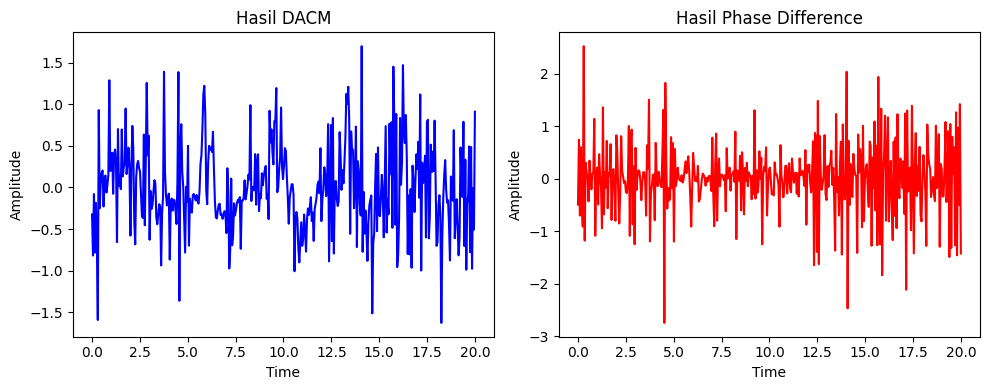

In [20]:
# Generate data for the signals
x = np.linspace(0, 20, 400)
signal1 = DACM_An1[:400]
signal2 = phase_an1[:400]

# Create a figure and axis objects
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Plot the first signal on the left subplot
ax1.plot(x, signal1, color='blue')
ax1.set_xlabel('Time')
ax1.set_ylabel('Amplitude')
ax1.set_title('Hasil DACM')

# Plot the second signal on the right subplot
ax2.plot(x, signal2, color='red')
ax2.set_xlabel('Time')
ax2.set_ylabel('Amplitude')
ax2.set_title('Hasil Phase Difference')

# Adjust the spacing between subplots
plt.tight_layout()

# Show the plot
plt.show()


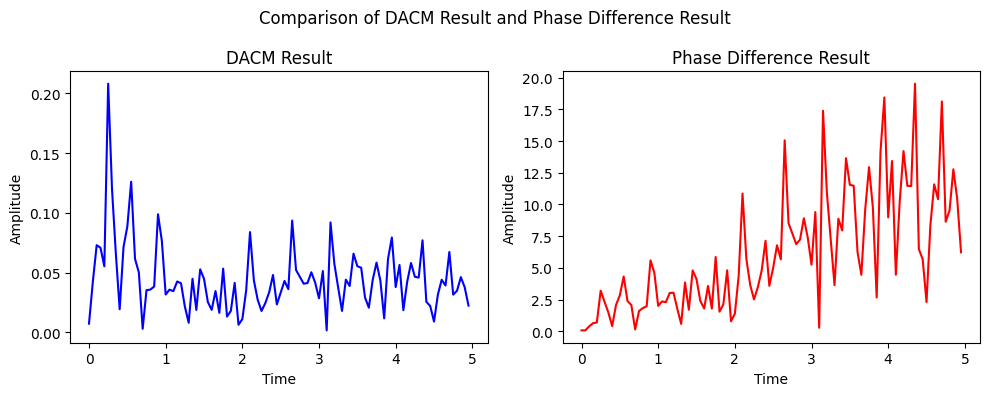

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Define the data
x = np.linspace(0, 20, 400)
signal1 = DACM_An2[:400]
signal2 = phase_an2[:400]
fr1, fft1 = fft_sinyal(signal1)
fft2 = fft(signal2)

# Create a figure and axis objects
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Plot the first signal on the left subplot
ax1.plot(fr1[:100], fft1[:100], color='blue')
ax1.set_xlabel('Time')
ax1.set_ylabel('Amplitude')
ax1.set_title('DACM Result')

# Plot the second signal on the right subplot
ax2.plot(fr1[:100], abs(fft2[:100]), color='red')
ax2.set_xlabel('Time')
ax2.set_ylabel('Amplitude')
ax2.set_title('Phase Difference Result')

# Set a title for the entire figure
plt.suptitle('Comparison of DACM Result and Phase Difference Result')

# Adjust the spacing between subplots
plt.tight_layout()

# Show the plot
plt.show()


In [22]:
def filter_RemoveImpulseNoise(dataPrev2, dataPrev1, dataCurr, thresh):
    pDataIn = []
    pDataIn.append(dataPrev2)
    pDataIn.append(dataPrev1)
    pDataIn.append(dataCurr)

    backwardDiff = pDataIn[1] - pDataIn[0]
    forwardDiff = pDataIn[1] - pDataIn[2]

    x1 = 0
    x2 = 2
    y1 = pDataIn[0]
    y2 = pDataIn[2]
    x = 1

    if ((forwardDiff > thresh and backwardDiff > thresh) or (forwardDiff < -thresh and backwardDiff < -thresh)):
        y = y1 + ((x - x1) * (y2 - y1) / (x2 - x1))
    else:
        y = pDataIn[1]
        
    return y

def remove_noise(delta_phase):
    thresh= 0.8
    data_hasil= []
#     n = (delta_phase.shape[0])-3
    for i in range(len(delta_phase)-3):# mulai data index ke-3 # mulai data index ke-3 
        dataPrev2 = delta_phase[i]# data[0] -> data(1)
        dataPrev1 = delta_phase[i+1]# data[1] -> data(2)
        dataCurr  = delta_phase[i+2] # data[2]
    #data_prev1.append(dataPrev1)
        y = filter_RemoveImpulseNoise(dataPrev2, dataPrev1, dataCurr, thresh)
        data_hasil.append(y)
    # data_hasil_AN = np.array(data_hasil)   
    return data_hasil


In [23]:
# DACM
NR_1 = np.array(remove_noise(DACM_An1),dtype=object)
NR_2 = np.array(remove_noise(DACM_An2),dtype=object)
NR_3 = np.array(remove_noise(DACM_An3),dtype=object)
NR_4 = np.array(remove_noise(DACM_An4),dtype=object)

In [24]:
def phase_dif(data):
    f = []
    for k in range(data.shape[0]-1):
        delta_phase = data[k + 1] - data[k]
        f.append(delta_phase)
    return f

In [25]:
# Phase Difference
# NR_1_hr = remove_noise(phase_dif(DACM_An1))
# NR_2_hr = remove_noise(phase_dif(DACM_An2))
# NR_3_hr = remove_noise(phase_dif(DACM_An3))
# NR_4_hr = remove_noise(phase_dif(DACM_An4))
# #
NR_1_hr = remove_noise(np.diff(DACM_An1))
NR_2_hr = remove_noise(np.diff(DACM_An2))
NR_3_hr = remove_noise(np.diff(DACM_An3))
NR_4_hr = remove_noise(np.diff(DACM_An4))

In [26]:
from scipy.signal import butter, sosfiltfilt, filtfilt
def _butter_bandpass(lowcut, highcut, fs, order):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    sos = butter(order, [low, high], btype="band", output="sos")
    return sos
def butter_bandpass_filter(signal, lowcut, highcut, fs, order):
    sos = _butter_bandpass(lowcut, highcut, fs, order=order)
    y = sosfiltfilt(sos, signal)
    return y

In [27]:
low = 0.1
high = 32/60
fs = 20
BPF_RR1 = np.array(butter_bandpass_filter(NR_1,low,high,fs,order=3))
BPF_RR2 = np.array(butter_bandpass_filter(NR_2,low,high,fs,order=3))
BPF_RR3 = np.array(butter_bandpass_filter(NR_3,low,high,fs,order=3))
BPF_RR4 = np.array(butter_bandpass_filter(NR_4,low,high,fs,order=3))


In [28]:
# Phase Difference 
low2 =0.8
high2 = 2
fs = 20
BPF_HR1 = np.array(butter_bandpass_filter(NR_1,low2,high2,fs,order=5))
BPF_HR2 = np.array(butter_bandpass_filter(NR_2,low2,high2,fs,order=5))
BPF_HR3 = np.array(butter_bandpass_filter(NR_3,low2,high2,fs,order=5))
BPF_HR4 = np.array(butter_bandpass_filter(NR_4,low2,high2,fs,order=5))

In [29]:
# Phase Difference 
low2 =0.8
high2 = 2
fs = 20
BPF_HR1v2 = np.array(butter_bandpass_filter(NR_1_hr,low2,high2,fs,order=5))
BPF_HR2v2 = np.array(butter_bandpass_filter(NR_2_hr,low2,high2,fs,order=5))
BPF_HR3v2 = np.array(butter_bandpass_filter(NR_3_hr,low2,high2,fs,order=5))
BPF_HR4v2 = np.array(butter_bandpass_filter(NR_4_hr,low2,high2,fs,order=5))

In [30]:

# Sliding Window 
def slid_win_20(data):
    isi_dataVT =[]
    for i in range(100):
        if i == 0:
            index_1 = i
        else :
            index_1 = index_2 - 380
        index_2 = index_1 + 400
        vt_20s_1 = data[index_1:index_2]
    #print(index_1,index_2)
        isi_dataVT.append(vt_20s_1)

    return isi_dataVT

In [31]:
# DACM RR
slid_an1_rr = np.array(slid_win_20(BPF_RR1),dtype=object)
slid_an2_rr = np.array(slid_win_20(BPF_RR2),dtype=object)
slid_an3_rr = np.array(slid_win_20(BPF_RR3),dtype=object)
slid_an4_rr = np.array(slid_win_20(BPF_RR4),dtype=object)

In [32]:
# DACM HR
slid_an1_hr = np.array(slid_win_20(BPF_HR1),dtype=object)
slid_an2_hr = np.array(slid_win_20(BPF_HR2),dtype=object)
slid_an3_hr = np.array(slid_win_20(BPF_HR3),dtype=object)
slid_an4_hr = np.array(slid_win_20(BPF_HR4),dtype=object)

In [33]:
# Phase Difference HR 
slid_an1_hr2 = np.array(slid_win_20(BPF_HR1v2),dtype=object)
slid_an2_hr2 = np.array(slid_win_20(BPF_HR2v2),dtype=object)
slid_an3_hr2 = np.array(slid_win_20(BPF_HR3v2),dtype=object)
slid_an4_hr2 = np.array(slid_win_20(BPF_HR4v2),dtype=object)

In [34]:
# Fungsi untuk menghitung amplitudo spektrum yang sudah dinormalisasi
def fft_sinyal(signal):
    sample_rate = 20
    
     # Melakukan FFT pada sinyal
    fft_data = np.fft.fft(signal, n=800)
    
    # Menghitung magnitudo spektrum FFT
    fft_magnitude = np.abs(fft_data)
    # Normalisasi amplitudo
    normalized_amplitude = 2.0 / len(signal) * fft_magnitude

    freq_axis = np.fft.fftfreq(len(fft_data), 1/sample_rate)
    
    # Ambil hanya data frekuensi positif
    freq_axis = freq_axis[:len(freq_axis)//2]
    normalized_amplitude = normalized_amplitude[:len(normalized_amplitude)//2]
    
    return freq_axis, normalized_amplitude

In [35]:
from scipy.signal import find_peaks
# explicit function to normalize array
def normalize(data, t_min, t_max):
    norm_arr = []
    diff = t_max - t_min
    diff_data = np.max(data) - np.min(data)   
    for i in data:
        temp = (((i - np.min(data))*diff)/diff_data) + t_min
        norm_arr.append(temp)

    t_norm_data = np.asarray(norm_arr, dtype='object')
    return t_norm_data

In [36]:
# Normalisasi 
def normalisasi_data(x, min_x,max_x):
    norm =[]
    for i in range(x.shape[0]):
        data = normalize(x[i],min_x,max_x)
        norm.append(data)
    return norm

# Bitalino 

In [37]:
#slid win 40 detik dengan geser 1 detik
from scipy.signal import find_peaks
# explicit function to normalize array
fs = 1000
def normalize(data, t_min, t_max):
    norm_arr = []
    diff = t_max - t_min
    diff_data = np.max(data) - np.min(data)   
    for i in data:
        temp = (((i - np.min(data))*diff)/diff_data) + t_min
        norm_arr.append(temp)

    t_norm_data = np.asarray(norm_arr, dtype='object')
    return t_norm_data

def slid_win40(data):
    isi_dataBR =[]
    for i in range(120):
        if i == 0:
            index_1 = i
        else :
            index_1 = index_2 - 19000
        index_2 = index_1 + 20000
        br_20s_1 = data[index_1:index_2]
        # print(index_1,index_2)
        isi_dataBR.append(br_20s_1)

    return isi_dataBR

def bpmbitalino(Hasil_BR_bit):
    lowcut_rr_ = 6/60
    highcut_rr_ = 32/60

    # bandpass_scaled = normalize(Hasil_BR_bit, 0, 1)
    # tHasil_BR_bit = butter_bandpass_filter(bandpass_scaled, lowcut_rr_, highcut_rr_, fs, order=2)
    frHasil_BR_bit = butter_bandpass_filter(Hasil_BR_bit, lowcut_rr_, highcut_rr_, fs, order=2)

    # Sliding Window BR 
    # Window_An1 = np.asarray(slid_win40(tHasil_BR_bit), dtype='object')
    Window_fft = np.asarray(slid_win40(frHasil_BR_bit), dtype='object')
    data_time = []
    data_freq =[]
    for i in range(len(Window_fft)):
        # Peak Time Domain
        # dataa1 = Window_An1[i]
        data2 = Window_fft[i]
        # peaks,_= find_peaks(dataa1, distance=1000, height=0.1, prominence=0.1)
        # time = np.linspace(0, 1000, 20000) #20 detik
        # # interval peak
        # jarak = (peaks/1000) #ubah dalam detik
        # jarak_diff = np.diff(jarak) 
        # ratarata = np.mean(jarak_diff)
        # intervalpeak = 60/ratarata
        # Peak FFT 
        n = len(data2)*2
        g = fft(data2,n)
        N = len(g)
        SAMPLE_RATE = 1000
        xf = fftfreq(N, 1 / SAMPLE_RATE)
        pk = np.argmax(abs(g[:50]))
        bpm = xf[pk]*60
        # data_time.append(intervalpeak)
        data_freq.append(bpm)
    # hasildata1 = np.asarray(data_time, dtype=object)
    hasildata2 = np.asarray(data_freq, dtype=object)
    return  hasildata2


In [38]:
freq_bit = bpmbitalino(bitalino)

In [39]:
def hasil_fft_rr(signal):
    hasil= []
    # x =[]
    # y =[]
    for i in range(signal.shape[0]):
        freq, fft_dat = fft_sinyal(signal[i])
        t = len(fft_dat)/2
        peaks = np.argmax(fft_dat)
        top_freq = freq[peaks]
        bpm_freq =top_freq*60
        hasil.append(bpm_freq)
    return hasil

In [40]:
def hasil_fft_hr(signal):
    hasil= []
    # x =[]
    # y =[]
    for i in range(signal.shape[0]):
        freq, fft_dat = fft_sinyal(signal[i])
        t = len(fft_dat)/2
        peaks = np.argmax(fft_dat)
        top_freq = freq[peaks]
        bpm_freq =top_freq*60
        hasil.append(bpm_freq)
    return hasil

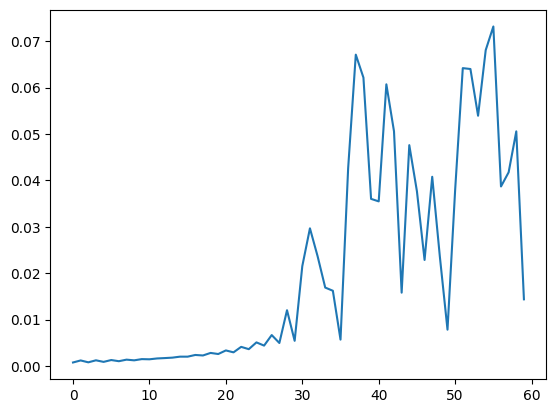

In [41]:
fr, fft_1 = fft_sinyal(slid_an1_hr[0])
plt.plot(fft_1[:60])

In [42]:
BPM_an1_rr = np.array(hasil_fft_rr(slid_an1_rr))
BPM_an2_rr = np.array(hasil_fft_rr(slid_an2_rr))
BPM_an3_rr = np.array(hasil_fft_rr(slid_an3_rr))
BPM_an4_rr = np.array(hasil_fft_rr(slid_an4_rr))

In [43]:
# DACM 
BPM_an1_hr = np.array(hasil_fft_hr(slid_an1_hr))
BPM_an2_hr = np.array(hasil_fft_hr(slid_an2_hr))
BPM_an3_hr = np.array(hasil_fft_hr(slid_an3_hr))
BPM_an4_hr = np.array(hasil_fft_hr(slid_an4_hr))

In [44]:
# Phase Difference
BPM_an1_hrv2 = np.array(hasil_fft_hr(slid_an1_hr2))
BPM_an2_hrv2 = np.array(hasil_fft_hr(slid_an2_hr2))
BPM_an3_hrv2 = np.array(hasil_fft_hr(slid_an3_hr2))
BPM_an4_hrv2 = np.array(hasil_fft_hr(slid_an4_hr2))

In [45]:
# Kalman 
def kalman_filter(z_ppg1):

    Q=20**2
    R=10**2
#     Q=4**2;                    
#     R=10**2;

    count=0
    countmax=5
    imax=3

    xposteriori=z_ppg1[0]
    res = np.zeros(len(z_ppg1))
    res[0]=z_ppg1[0]
    Pposteriori=0
    hasil =[]

    for i in range (1, len(z_ppg1)):

        xpriori=xposteriori
        Ppriori=Pposteriori+Q

        S=Ppriori+R
        gain=Ppriori/S

        inn1=z_ppg1[i]-xpriori

        if (((count==countmax or i<imax) and ~np.isnan(inn1))):
            inn=inn1
            xposteriori=xpriori+gain*inn
            Pposteriori=(1-gain)*Ppriori
            if(count==countmax ):
                xposteriori=0.5*(z_ppg1[i]+xpriori)
            count=0

        else:
            count=count+1
            xposteriori=xpriori
            Pposteriori=Ppriori

        res[i]=xposteriori
        hasil.append(xposteriori)

    return hasil

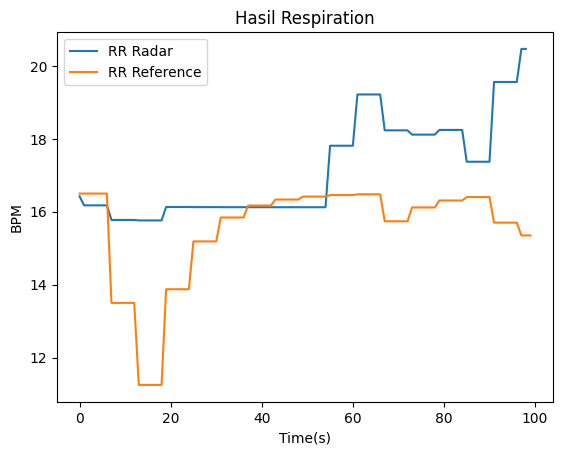

In [46]:
RR1 = np.array(BPM_an1_rr)
RR2 = np.array(BPM_an2_rr)
RR3 = np.array(BPM_an3_rr)
RR4 = np.array(BPM_an4_rr)
final_rr = (RR1+RR2+RR3+RR4)/4
RR_kal= kalman_filter(final_rr[:240])
ref_rr = kalman_filter(freq_bit)
plt.title("Hasil Respiration")
plt.plot(RR_kal, label="RR Radar")
plt.plot(ref_rr[12:112],label="RR Reference")
plt.xlabel("Time(s)")
plt.ylabel("BPM")
plt.legend()

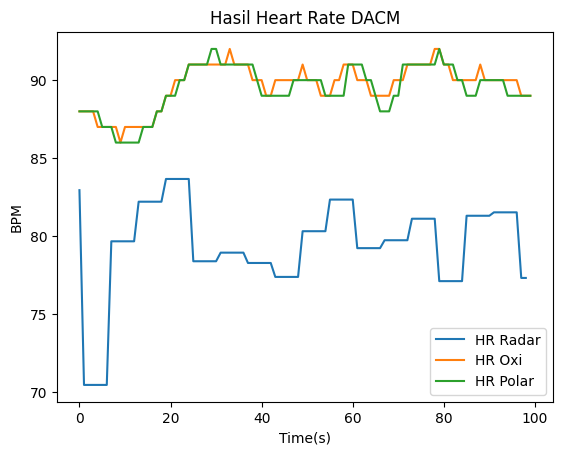

In [47]:
HR1 = np.array(BPM_an1_hr)
HR2 = np.array(BPM_an2_hr)
HR3 = np.array(BPM_an3_hr)
HR4 = np.array(BPM_an4_hr)
final_HR = (HR1+HR2+HR3+HR4)/4
HR_kal= kalman_filter(final_HR[:100])
ref_ox =pol[20:]
ref_pol = ox[20:]
plt.title("Hasil Heart Rate DACM")
plt.plot(HR_kal, label="HR Radar")
plt.plot(ref_ox,label="HR Oxi")
plt.plot(ref_pol,label="HR Polar")
plt.xlabel("Time(s)")
plt.ylabel("BPM")
plt.legend()

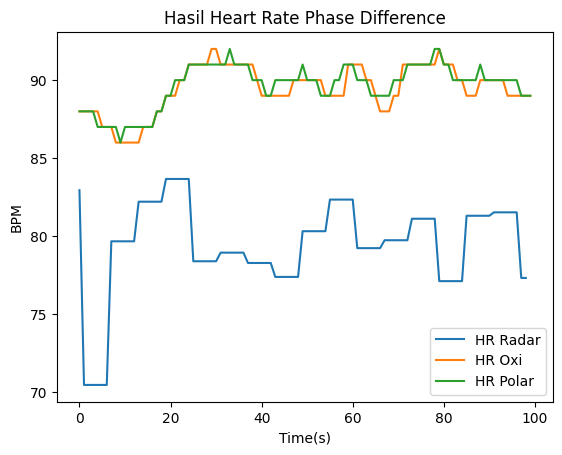

In [48]:
HR1_2 = np.array(BPM_an1_hrv2)
HR2_2 = np.array(BPM_an2_hrv2)
HR3_2 = np.array(BPM_an3_hrv2)
HR4_2 = np.array(BPM_an4_hrv2)
final_HR2 = (HR1_2+HR2_2+HR3_2+HR4_2)/4
HR_kal2= kalman_filter(final_HR2[:100])
ref_ox =ox[20:]
ref_pol = pol[20:]
plt.title("Hasil Heart Rate Phase Difference")
plt.plot(HR_kal, label="HR Radar")
plt.plot(ref_ox,label="HR Oxi")
plt.plot(ref_pol,label="HR Polar")
plt.xlabel("Time(s)")
plt.ylabel("BPM")
plt.legend()

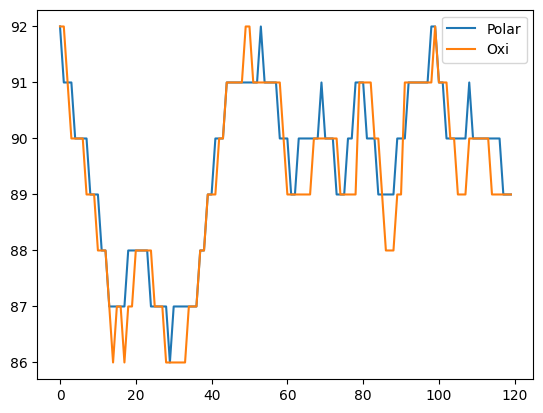

In [49]:
plt.plot(pol, label='Polar')
plt.plot(ox, label='Oxi')
plt.legend()

In [50]:
import math
from sklearn.metrics import mean_squared_error
def RMSE(actual, predicted):
    y_actual = actual
    y_predicted =predicted
    MSE = np.square(np.subtract(y_actual,y_predicted)).mean() 
    RMSE = math.sqrt(MSE)
    return np.round(RMSE,2)

def mae(y_true, predictions):
    y_true, predictions = np.array(y_true), np.array(predictions)
    m =np.mean(np.abs(y_true - predictions))
    return np.round(m,2)

In [51]:
data_radar = np.round(RR_kal,0)
data_bit = np.round(ref_rr[12:111],0)
mae_rr = mae(data_radar,data_bit)
# mae2 = mae(kal_bit_time,RR_final_kal_20s)

# RMSE 
RMSE_rr = RMSE(data_radar,data_bit)
# RMSE2 = RMSE(kal_bit_time,RR_final_kal_20s)
print("MAE : ", mae_rr)
print("RMSE : ", RMSE_rr )

MAE :  1.68
RMSE :  2.26


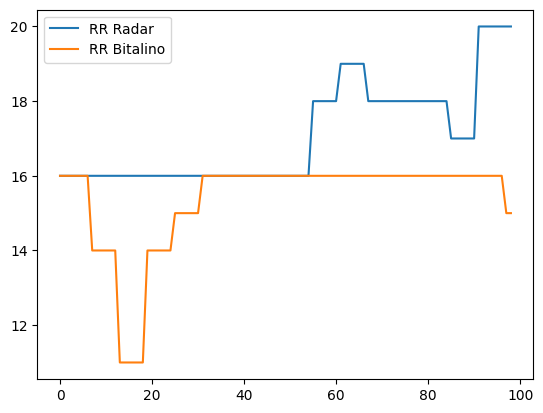

In [52]:
plt.plot(data_radar, label="RR Radar")
plt.plot(data_bit, label="RR Bitalino")
plt.legend()

In [53]:
hr_radarv1 = np.round(final_HR,0)
hr_radarv2 = np.round(final_HR,0)
data_oxi =np.round(ref_ox,0)
data_pol =np.round(ref_pol,0)
# Oximeter
mae_hrv1_ox = mae(hr_radarv1,data_oxi)
mae_hrv2_ox = mae(hr_radarv2,data_oxi)
# Polar 
mae_hrv1_pol = mae(hr_radarv1,data_pol)
mae_hrv2_pol = mae(hr_radarv2,data_pol)
# RMSE 
# Oximeter
rmse_hrv1_ox = RMSE(hr_radarv1,data_oxi)
rmse_hrv2_ox = RMSE(hr_radarv2,data_oxi)
# Polar 
rmse_hrv1_pol = RMSE(hr_radarv1,data_pol)
rmse_hrv2_pol = RMSE(hr_radarv2,data_pol)
print("MAE-1 DACM OX: ", mae_hrv1_ox)
print("RMSE-1 DACM OX : ", rmse_hrv1_ox)
print("MAE-1 DACM POl: ", mae_hrv1_pol)
print("RMSE-1 DACM POl : ",rmse_hrv1_pol)
# V2
print("MAE-2 DACM OX: ", mae_hrv2_ox)
print("RMSE-2 DACM OX : ", rmse_hrv2_ox)
print("MAE-2 DACM POl: ", mae_hrv2_pol)
print("RMSE-2 DACM POl : ",rmse_hrv2_pol)


MAE-1 DACM OX:  9.9
RMSE-1 DACM OX :  11.05
MAE-1 DACM POl:  10.02
RMSE-1 DACM POl :  11.13
MAE-2 DACM OX:  9.9
RMSE-2 DACM OX :  11.05
MAE-2 DACM POl:  10.02
RMSE-2 DACM POl :  11.13


In [54]:



# list1 = [mae_rr,0] 
# list2 = [RMSE_rr,0]
# # V1
# list3 = [mae_hrv1_ox,0] 
# list4 = [rmse_hrv1_ox,0]
# list5 = [mae_hrv1_pol,0] 
# list6 = [rmse_hrv1_pol,0] 
# #V2
# list7 = [mae_hrv2_ox,0] 
# list8 = [rmse_hrv2_ox,0]
# list9 = [mae_hrv2_pol,0] 
# list10 = [rmse_hrv2_pol,0] 




# col1 = "MAE RR"
# col2 = "RMSE RR"
# col3 = "MAE HR DACM OX"
# col4 = "RMSE HR DACM OX"
# col5 = "MAE HR DACM POl"
# col6 = "RMSE HR DACM POl"
# col7 = "MAE HR PH Diff OX"
# col8 = "RMSE HR PH Diff OX"
# col9 = "MAE HR PH Diff POl"
# col10 = "RMSE HR PH Diff POl"

# name1 = 'Hasil RR dan HR Subjek-{} {} BPM 20 Juni.xlsx'
# data_br = pd.DataFrame({col1:list1, col2:list2, col3:list3,col4:list4, col5:list5,col6:list6, col7:list7, col8:list8,col9:list9,col10:list10})
# data_br.to_excel(name1.format(user_name,subject_id), sheet_name='sheet1', index=False)
# print("Selesai Menulis")

In [55]:
a = [0] * 99
a[0] = mae_rr
b = [0]*99
b[0] = RMSE_rr
c = [0]*99
c[0] = mae_hrv1_pol
d = [0]*99
d[0] = rmse_hrv1_pol

In [56]:
RMSE_rr

2.26

In [57]:
# hr_radarv1 = np.round(final_HR,0)
# hr_radarv2 = np.round(final_HR,0)
# data_radar = np.round(RR_kal,0)
# data_bit = np.round(ref_rr[12:111],0)

In [58]:
# Tulis HR dan RR 
l1 = data_radar[:99] # Radar 
l2 = data_bit[:99] # Bitalino 
l3 = hr_radarv1[:99] # HR Radar 
l4 = data_pol[:99]
l5 = a # Mae RR
l6 = b # RMSE RR
l7 = c # MAE HR 
l8 = d # RMSE HR 

col1 = "RR"
col2 = "RR Bitalino"
col3 = "MAE RR"
col4 = "RMSE RR"
col5 = "HR Radar"
col6 = "HR Polar"
col7 = "MAE HR"
col8 = "RR HR"

name1 = 'Hasil 30 Juni RR dan HR Subjek-{} {} BPM.xlsx'
data_br = pd.DataFrame({col1:l1, col2:l2, col3:l5,col4:l6, col5:l3,col6:l4,col7:l7,col8:l8})
data_br.to_excel(name1.format(user_name,subject_id), sheet_name='sheet1', index=False)
print("Selesai Menulis")

Selesai Menulis


In [59]:
min1 = np.min(l1)
max1 = np.max(l1)
# 
min2 = np.min(l2)
max2 = np.max(l2)

print("Radar min :", min1)
print("Radar Max :", max1)
print("Bitalino min :",min2)
print("Bitalino Max :", max2)


Radar min : 16.0
Radar Max : 20.0
Bitalino min : 11.0
Bitalino Max : 16.0
